# Concept figure: what the dark-microhalo astrometric signal looks like

Produces **`figs/concept.pdf`** (Fig. 2 of the paper).

Simulates a Gaussian realization of the stochastic image-pair separation
$\delta\theta^\mathrm{A,B}(t)$ for the galaxy lens B1422+231, drawn from the
*analytic* power spectral density $\widetilde{C}_{pq}(\omega)$ of Eq. (C)
(subhalo mass $M_\mathrm{L} = 10^{-4}\,M_\odot$, scale density
$\rho_s = 10\,M_\odot\,\mathrm{pc^{-3}}$, $f_\mathrm{sub} = 0.5$ --- the same
fiducial as the `CtildeA.pdf` panel of `sensitivity.ipynb`), samples it with the
fiducial EPIC campaign ($\tau = 10\,$yr, $N = 300$,
$\sigma_{\delta\theta} = 0.1\,\mu$as), and shows:

1. the **sky-plane trajectory** of the image-pair separation after subtracting the
   best-fit linear relative motion --- the random walk induced by dark microhalos,
   resolved by half-year (15-epoch) averages of the data;
2. the **dominant component versus time** with the best-fit quadratic overlaid:
   when individual halo crossings are not time-resolved, the random walk shows up
   as an anomalous differential acceleration --- the Eq. (observable_2) statistic.

Only the galaxy lens is illustrated here; the cluster-lens analogue of the
underlying PSD and acceleration response is in Part II of `sensitivity.ipynb`.

*Runtime: a few seconds.*

## Setup

In [1]:
from preamble import *
from natural_units_GeV import *
from macro_lens_functions import *
from sensitivity_functions import *
from params_B1422_231 import *

colors = sns.color_palette(xgfs_fancy6)

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_500 =  0.040 muas = 0.195e-12 rad
theta_E_star =  1.400 muas


## Fiducial configuration

Macro-lens quantities ($B^\mathrm{I} = $ `inv_jacobian_fit`, $\kappa^\mathrm{I}$)
come from `macro_lens.ipynb`. The image--subhalo sweep rate uses the bulk lens
velocity magnified by $B^\mathrm{I}$, with the subhalos' internal motion added
*unmagnified* in quadrature (see `params_B1422_231.py`).

In [2]:
res = np.load('macro_lens_results.npz')
inv_jacobian_fit = res['inv_jacobian_fit']; kappa_fit = res['kappa_fit']
v_lens = v_lens_fid   # BULK fiducial, |v_L| ~ 865 km/s (see params_B1422_231)
vec_mu = mu_rel(np.zeros(2)*km/second, v_lens, np.zeros(2)*km/second,
                z_lens, z_source, d_lens, d_source, d_lens_source)
vec_mu_tilde = np.tensordot(inv_jacobian_fit, vec_mu, axes=1)
# sweep rate: bulk magnified by B, internal subhalo motion UNMAGNIFIED
mu_tilde = np.sqrt(np.linalg.norm(vec_mu_tilde, axis=1)**2 + mu_int_drift**2)
zeta = np.arctan2(vec_mu_tilde[:, 1], vec_mu_tilde[:, 0])

t_int = 10 * year
N_obs = 300
sigma_dth = 0.1 * muas
f_sub = 0.5
M_L = 1e-4 * M_Solar
rho_s = 10 * M_Solar / pc**3
r_s = (M_L/(rho_s*(4*np.pi*np.exp(1/2))))**(1/3)
gamma_L = r_s / d_lens
theta_E_L = theta_E(M_L, d_lens, d_source, d_lens_source)

print('mu_tilde = %s muas/yr' % np.round(mu_tilde/muasy, 3))
print('gamma_L  = %.3g muas,  theta_E_L = %.3g muas' % (gamma_L/muas, theta_E_L/muas))

mu_tilde = [0.987 1.384 0.504 0.065] muas/yr
gamma_L  = 1.62 muas,  theta_E_L = 0.0256 muas


## Differential PSD of the A,B image pair

$\widetilde{C}^\mathrm{A,B}_{pq} = \widetilde{C}^\mathrm{A}_{pq} + \widetilde{C}^\mathrm{B}_{pq}$
(the two images see statistically independent subhalo fields), each macro-lensed
by its own $B^\mathrm{I}$.

In [3]:
vec_omega = np.logspace(np.log10(2*np.pi/(20*t_int)), np.log10(np.pi*N_obs/t_int), 4000)
arr_C = np.zeros((2, 2, len(vec_omega)))
for i in [0, 1]:   # images A, B
    C_ij = f_sub*kappa_fit[i]*theta_E_L**2/vec_omega * C_ij_integral(gamma_L/mu_tilde[i]*vec_omega, zeta[i])
    arr_C += np.einsum('qj,pjm->pqm', inv_jacobian_fit[i], np.einsum('pi,ijm->pjm', inv_jacobian_fit[i], C_ij))

## Gaussian realization and the fitted acceleration

Each frequency bin contributes an independent 2D Gaussian with covariance
$\widetilde{C}_{pq}(\omega_n)\,\Delta\omega_n/\pi$; summing cosine and sine
components gives a time series with the prescribed spectrum. We then remove the
best-fit constant and linear motion (degenerate with the macro-lens model) and
compare the fitted quadratic to the rms expectation from the same smeared
$\omega^4$ moment of the PSD that defines Eq. (observable_2).

In [4]:
t_obs = np.linspace(-t_int/2, t_int/2, N_obs)
d_omega = np.gradient(vec_omega)

def realization(seed):
    rng = np.random.default_rng(seed)
    theta_t = np.zeros((2, N_obs))
    for n in range(len(vec_omega)):
        Cn = arr_C[:, :, n] * d_omega[n] / np.pi          # per-mode 2x2 covariance
        L = np.linalg.cholesky(Cn + 1e-40*np.eye(2))
        a = L @ rng.standard_normal(2); b = L @ rng.standard_normal(2)
        theta_t += np.outer(a, np.cos(vec_omega[n]*t_obs)) + np.outer(b, np.sin(vec_omega[n]*t_obs))
    return theta_t

# rms expectation of the fitted differential acceleration from the PSD itself
# (same smeared omega^4 integral as the acc figure / Eq. observable_2)
def smear_fac_acc(a):
    return np.heaviside(-a + 1e-2, 0) + np.heaviside(a - 1e-2, 0) * 14400 * (
        6*a*np.cos(a/2) + (-12 + a**2)*np.sin(a/2))**2 / a**10
acc_cov = 2*np.sum(smear_fac_acc(vec_omega*t_int) * d_omega/(2*np.pi) * vec_omega**4 * arr_C, axis=-1)
acc_rms = np.sqrt(np.max(np.real(np.linalg.eigvals(acc_cov))))
print('rms fitted |acc| expectation = %.2g muas/yr^2' % (acc_rms/muasyy))

rms fitted |acc| expectation = 0.016 muas/yr^2


### Pick a representative realization

We scan seeds for the first realization whose fitted acceleration lands near the
rms expectation, so the figure shows a *typical* --- not a cherry-picked ---
outcome.

In [5]:
seed = 0
for s in range(60):
    th = realization(s)
    # remove best-fit constant + linear motion (degenerate with macro-model)
    resid = np.array([th[c] - np.polyval(np.polyfit(t_obs, th[c], 1), t_obs) for c in [0, 1]])
    acc_fit = np.array([2*np.polyfit(t_obs, resid[c], 2)[0] for c in [0, 1]])
    if 0.9 < np.linalg.norm(acc_fit)/acc_rms < 1.4:
        seed = s; break
print('seed =', seed, '| fitted |acc| = %.2g muas/yr^2' % (np.linalg.norm(acc_fit)/muasyy))

rng = np.random.default_rng(1000 + seed)
noise = sigma_dth * rng.standard_normal((2, N_obs))
data = resid + noise                                  # linear-detrended data + noise

# half-year (15-epoch) averages: the analysis-level view of the random walk
n_bin = 15
n_grp = N_obs // n_bin
t_b = t_obs[:n_grp*n_bin].reshape(n_grp, n_bin).mean(axis=1)
data_b = data[:, :n_grp*n_bin].reshape(2, n_grp, n_bin).mean(axis=2)
sigma_b = sigma_dth / np.sqrt(n_bin)

# quadratic fit to the dominant component (on the full-resolution data)
c_dom = int(np.argmax(np.var(resid, axis=1)))
p2 = np.polyfit(t_obs, data[c_dom], 2)
acc_meas = 2*p2[0]
sigma_acc = np.sqrt(720)*sigma_dth/np.sqrt(N_obs*t_int**4)
chi2_red = np.sum((data[c_dom] - np.polyval(p2, t_obs))**2 / sigma_dth**2) / (N_obs - 3)
print('component %d: fitted acc = %.2g +- %.2g muas/yr^2 | chi2_red = %.2f'
      % (c_dom, acc_meas/muasyy, sigma_acc/muasyy, chi2_red))

seed = 0 | fitted |acc| = 0.021 muas/yr^2
component 1: fitted acc = -0.014 +- 0.0015 muas/yr^2 | chi2_red = 0.99


## Figure  →  `figs/concept.pdf`

saved ../figs/concept.pdf


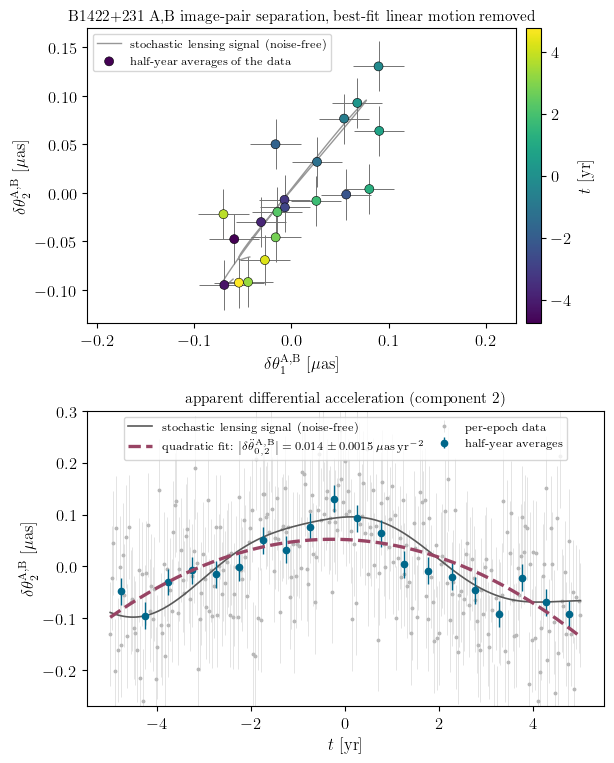

In [6]:
fig, (axa, axb) = plt.subplots(2, 1, figsize=(6.3, 7.8))

# (a) sky-plane random walk of the pair separation (linear motion removed)
axa.plot(resid[0]/muas, resid[1]/muas, color=(0.55, 0.55, 0.55), lw=1.0, alpha=0.9, zorder=2,
         label='stochastic lensing signal (noise-free)')
sc = axa.scatter(data_b[0]/muas, data_b[1]/muas, c=(t_b/year), cmap='viridis', s=42,
                 edgecolor='k', linewidths=0.4, zorder=4, label=r'half-year averages of the data')
axa.errorbar(data_b[0]/muas, data_b[1]/muas, xerr=sigma_b/muas, yerr=sigma_b/muas,
             fmt='none', ecolor=(0.45, 0.45, 0.45), elinewidth=0.7, zorder=3)
cb = fig.colorbar(sc, ax=axa, pad=0.02); cb.set_label(r'$t~[\mathrm{yr}]$')
axa.set_xlabel(r'$\delta\theta_1^\mathrm{A,B}~[\mathrm{\mu as}]$')
axa.set_ylabel(r'$\delta\theta_2^\mathrm{A,B}~[\mathrm{\mu as}]$')
axa.set_title(r'B1422+231 A,B image-pair separation, best-fit linear motion removed', fontsize=11)
axa.legend(loc='upper left', fontsize=8.5)
axa.set_aspect('equal', adjustable='datalim')

# (b) dominant component vs time with the quadratic (acceleration) fit
axb.errorbar(t_obs/year, data[c_dom]/muas, yerr=sigma_dth/muas, fmt='o', ms=1.8,
             color=(0.72, 0.72, 0.72), ecolor=(0.85, 0.85, 0.85), elinewidth=0.5, zorder=1,
             label=r'per-epoch data')
axb.errorbar(t_b/year, data_b[c_dom]/muas, yerr=sigma_b/muas, fmt='o', ms=4.5,
             color=colors[3], ecolor=colors[3], elinewidth=1.0, zorder=4,
             label=r'half-year averages')
axb.plot(t_obs/year, resid[c_dom]/muas, color=(0.35, 0.35, 0.35), lw=1.2, zorder=3,
         label='stochastic lensing signal (noise-free)')
axb.plot(t_obs/year, np.polyval(p2, t_obs)/muas, color=colors[4], lw=2.4, ls='dashed', zorder=5,
         label=r'quadratic fit: $\big|\delta\ddot\theta_{0,%d}^{\mathrm{A,B}}\big| = %.2g \pm %.2g\,\mathrm{\mu as\,yr^{-2}}$'
               % (c_dom+1, abs(acc_meas)/muasyy, sigma_acc/muasyy))
axb.set_xlabel(r'$t~[\mathrm{yr}]$')
axb.set_ylabel(r'$\delta\theta_%d^\mathrm{A,B}~[\mathrm{\mu as}]$' % (c_dom+1))
axb.set_ylim(-0.27, 0.30)
axb.set_title(r'apparent differential acceleration (component %d)' % (c_dom+1), fontsize=11)
axb.legend(loc='upper center', fontsize=8.5, ncol=2, columnspacing=0.8)

fig.tight_layout()
fig.savefig('../figs/concept.pdf', bbox_inches='tight')
print('saved ../figs/concept.pdf')
plt.show()